# 02 · ENSO phase assignment and selecting the days

**Goal.** Turn the daily precipitation series from notebook 01 into a defensible list of
"heavy rainfall days under El Niño" — the sample that the SOM in notebook 04 is trained on.

Two decisions carry most of the scientific weight here, and both are choices rather than
defaults:

1. **Which ENSO index.** Niño 1+2, not Niño 3.4.
2. **Which precipitation metric to rank.** Province mean, not spatial maximum.

Both are argued below, and the second is shown to change the answer materially.

## Why Niño 1+2 rather than Niño 3.4

Niño 3.4 (5°N–5°S, 170°W–120°W) is the standard index for *global* ENSO teleconnections and is
what most seasonal forecasts key on. But Ecuador sits directly against the **Niño 1+2** region
(0–10°S, 90°W–80°W) — the far-eastern equatorial Pacific, immediately offshore.

Coastal Ecuadorian rainfall responds to *local* SST: warm water offshore destabilizes the
boundary layer and shifts the ITCZ south over the coast. Events can be strong in Niño 1+2 while
modest in Niño 3.4 — the 2017 and 2023 "coastal El Niño" events are exactly this case, and both
produced severe flooding. Using Niño 3.4 would underweight precisely the events that matter most
here.

> If you adapt this workflow to another region, revisit this choice first. It is the single most
> region-specific decision in the whole chain.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append("../src")
from config import DATA_DIR, NINO12_THRESHOLDS

series = pd.read_csv(DATA_DIR / "guayas_daily_series.csv", parse_dates=["date"])
print(series.shape, series.date.min().date(), "->", series.date.max().date())

(16648, 3) 1981-01-01 -> 2026-07-31


## 1. A daily ENSO index from a monthly product

CPC publishes Niño-region SST anomalies **monthly**. We are classifying **daily** precipitation,
so the index has to be interpolated to daily resolution.

Monthly values are assigned to **mid-month** and linearly interpolated, which is the convention
that avoids a systematic half-month phase lag. Placing a monthly mean at the 1st of the month
instead would shift the whole index ~15 days early — enough to misclassify days near a
threshold crossing during a rapidly developing event.

Anomalies are relative to the **1991–2020** base period (the current CPC standard).

In [2]:
def daily_nino_index(monthly: pd.DataFrame, col="nino12_anom") -> pd.DataFrame:
    """Monthly anomalies -> daily, via mid-month anchoring + linear interpolation.

    `monthly` needs columns: year, month, <col>.
    """
    m = monthly.copy()
    # mid-month anchor: day 15 of each month
    m["date"] = pd.to_datetime(dict(year=m.year, month=m.month, day=15))
    m = m.sort_values("date").set_index("date")

    daily_idx = pd.date_range(m.index.min(), m.index.max(), freq="D")
    daily = m[[col]].reindex(daily_idx).interpolate(method="time")
    daily.index.name = "date"
    return daily.reset_index()

# The prepared daily index ships with the repo (built from CPC monthly ERSST Nino-region anomalies).
enso = pd.read_csv(DATA_DIR / "enso_daily_1981-present.csv", parse_dates=["date"])
print(enso.shape)
print(enso.head(3).to_string(index=False))
print("\nanomaly range:", round(enso.nino12_anom.min(), 2), "to", round(enso.nino12_anom.max(), 2), "deg C")

(16674, 12)
      date  nino12_sst  nino12_anom  nino3_sst  nino3_anom  nino34_sst  nino34_anom  nino4_sst  nino4_anom            sst_source  oni_anom enso_phase
1981-01-01      22.766       -1.003     25.076      -0.385      26.392       -0.175     28.335      -0.085 monthly_ersst5_interp     -0.27    neutral
1981-01-02      22.787       -1.039     25.067      -0.408      26.377       -0.188     28.324      -0.088 monthly_ersst5_interp     -0.27    neutral
1981-01-03      22.808       -1.074     25.058      -0.431      26.362       -0.201     28.314      -0.091 monthly_ersst5_interp     -0.27    neutral

anomaly range: -2.5 to 4.5 deg C


## 2. Phase classification

Four phases, from the daily Niño 1+2 anomaly:

| Phase | Threshold | Rationale |
|---|---|---|
| `super_el_nino` | ≥ +2.0 °C | Separates the exceptional events (1982-83, 1997-98, 2023) from routine warm years |
| `regular_el_nino` | +0.5 to +2.0 °C | Conventional El Niño threshold |
| `neutral` | −0.5 to +0.5 °C | |
| `la_nina` | ≤ −0.5 °C | |

The ±0.5 °C boundary is the conventional ENSO threshold. The +2.0 °C "super" cut is a deliberate
addition for this analysis: Niño 1+2 anomalies during coastal events reach values where the
rainfall response is plausibly non-linear, and lumping them with +0.6 °C days would hide that.

> **A caveat to carry forward.** Classifying *individual days* by ENSO state conflates the ENSO
> signal with the annual cycle, because El Niño days are not uniformly distributed across
> calendar months even within the wet season. A stricter variant would stratify thresholds by
> month. We keep the simple version but flag it wherever results are reported.

In [3]:
def classify_nino12(a: float) -> str:
    if a >= NINO12_THRESHOLDS["super"]:
        return "super_el_nino"
    if a >= NINO12_THRESHOLDS["regular"]:
        return "regular_el_nino"
    if a > -NINO12_THRESHOLDS["regular"]:
        return "neutral"
    return "la_nina"

print(NINO12_THRESHOLDS)

df = series.set_index("date").join(enso.set_index("date")[["nino12_anom"]], how="inner").reset_index()
df["phase"] = df["nino12_anom"].apply(classify_nino12)

PHASES = ["super_el_nino", "regular_el_nino", "neutral", "la_nina"]
base_counts = df["phase"].value_counts().reindex(PHASES)
base_rate = base_counts / len(df) * 100

print("\njoined record:", len(df), "days")
print("\nbase rates over the whole record:")
print(pd.DataFrame({"n_days": base_counts, "pct": base_rate.round(2)}))

{'super': 2.0, 'regular': 0.5}

joined record: 16648 days

base rates over the whole record:
                 n_days    pct
phase                         
super_el_nino      1148   6.90
regular_el_nino    3244  19.49
neutral            5769  34.65
la_nina            6487  38.97


These base rates are the **reference** for everything that follows. A phase making up 19.5% of
the top-250 wettest days is only interesting relative to how often that phase occurs at all —
which is the normalization in section 4.

## 3. Rank the days — and watch the two metrics disagree

Now we take the top 250 wettest days, by each of the two metrics from notebook 01, and ask what
ENSO phase they fall in.

In [4]:
N_TOP = 250
results = {}

for metric in ["mean_mm", "max_mm"]:
    top = df.nlargest(N_TOP, metric)
    counts = top["phase"].value_counts().reindex(PHASES).fillna(0).astype(int)
    tab = pd.DataFrame({
        "n_days": counts,
        "pct_of_top": (counts / N_TOP * 100).round(1),
        "base_rate_pct": base_rate.round(1),
    })
    # enrichment = P(phase | extreme day) / P(phase) -- the frequency normalization
    tab["enrichment"] = (tab["pct_of_top"] / tab["base_rate_pct"]).round(2)
    results[metric] = tab
    print(f"--- ranked by {metric} (threshold: {top[metric].min():.1f} mm/day) ---")
    print(tab)
    print()

--- ranked by mean_mm (threshold: 38.5 mm/day) ---
                 n_days  pct_of_top  base_rate_pct  enrichment
phase                                                         
super_el_nino        37        14.8            6.9        2.14
regular_el_nino     100        40.0           19.5        2.05
neutral              76        30.4           34.7        0.88
la_nina              37        14.8           39.0        0.38

--- ranked by max_mm (threshold: 162.2 mm/day) ---
                 n_days  pct_of_top  base_rate_pct  enrichment
phase                                                         
super_el_nino        17         6.8            6.9        0.99
regular_el_nino      74        29.6           19.5        1.52
neutral             111        44.4           34.7        1.28
la_nina              48        19.2           39.0        0.49



## 4. Normalizing by frequency of occurrence

The `enrichment` column is the number that actually answers "does El Niño make extreme rainfall
more likely?":

$$\text{enrichment} = \frac{P(\text{phase} \mid \text{top-250 day})}{P(\text{phase})}$$

- **> 1** — the phase is *overrepresented* among extreme days
- **= 1** — extreme days occur in this phase exactly as often as the phase itself occurs
- **< 1** — *underrepresented*

Reporting raw percentages without this normalization is misleading: La Niña accounts for a large
share of extreme days simply because La Niña days are common in the record.

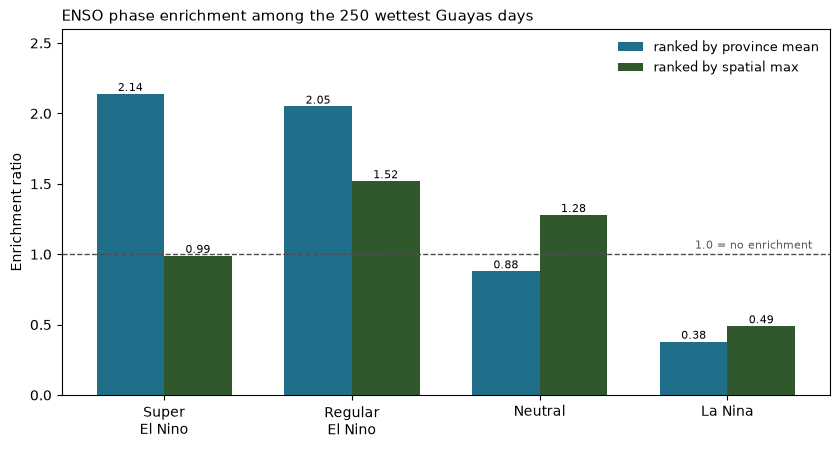

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
x = np.arange(4)
w = 0.36
labels = ["Super\nEl Nino", "Regular\nEl Nino", "Neutral", "La Nina"]

b1 = ax.bar(x - w/2, results["mean_mm"]["enrichment"], width=w,
            color="#1f6f8b", label="ranked by province mean")
b2 = ax.bar(x + w/2, results["max_mm"]["enrichment"], width=w,
            color="#31572c", label="ranked by spatial max")
ax.axhline(1.0, color="0.3", ls="--", lw=1.0)
ax.text(3.45, 1.04, "1.0 = no enrichment", fontsize=8, color="0.35", ha="right")

for bars in (b1, b2):
    for r in bars:
        ax.annotate(f"{r.get_height():.2f}", (r.get_x() + r.get_width()/2, r.get_height()),
                    xytext=(0, 2), textcoords="offset points", ha="center", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Enrichment ratio")
ax.set_ylim(0, 2.6)
ax.legend(frameon=False, fontsize=9)
ax.set_title("ENSO phase enrichment among the 250 wettest Guayas days", loc="left", fontsize=11)
fig.tight_layout()

**The metrics genuinely disagree, and the disagreement is the interesting result.**

Super El Niño is strongly overrepresented among the wettest *province-mean* days but shows
essentially no enrichment among the wettest *single-cell* days. Read physically: the strongest
warm events drive **widespread, organized** heavy rainfall across the province, but they do not
make an individual convective cell more intense than it would be in neutral conditions. Intense
localized bursts happen largely independently of ENSO phase.

This is why the metric choice has to be made explicitly and stated in every result. For the rest
of this workflow we rank by **province mean**, because the question motivating the analysis is
province-scale flood risk, not point-scale intensity.

## 5. The El Niño subset — the SOM's training sample

Take the top-250 province-mean days, keep only those in an El Niño phase (super or regular).
This is the sample the SOM classifies.

In [6]:
top_mean = df.nlargest(N_TOP, "mean_mm").sort_values("date").reset_index(drop=True)
heavy_enso = top_mean[top_mean["phase"].isin(["super_el_nino", "regular_el_nino"])].copy()
heavy_enso = heavy_enso.reset_index(drop=True)

print("heavy El Nino days:", len(heavy_enso))
print("date span:", heavy_enso.date.min().date(), "->", heavy_enso.date.max().date())
print("\nphase composition:")
print(heavy_enso["phase"].value_counts())
print("\ndays per calendar month (note the Dec-May concentration):")
print(heavy_enso.date.dt.month.value_counts().sort_index())

heavy El Nino days: 137
date span: 1983-01-16 -> 2026-03-12

phase composition:
phase
regular_el_nino    100
super_el_nino       37
Name: count, dtype: int64

days per calendar month (note the Dec-May concentration):
date
1    15
2    43
3    51
4    26
5     2
Name: count, dtype: int64


In [7]:
# save the day list -- this is the hand-off to notebook 03
out = DATA_DIR / "heavy_enso_positive_days.csv"
heavy_enso[["date", "mean_mm", "max_mm", "nino12_anom", "phase"]].to_csv(out, index=False)
print("wrote", out)
heavy_enso.head(8).to_string(index=False)

wrote /Users/snesbitt/.claude-science/orgs/6a2220b0-49b1-45ab-a891-23ce4097f835/workspaces/d6236080-0839-49c3-a3ca-b04e592b5786/ecuador-enso-som/data/heavy_enso_positive_days.csv


'      date   mean_mm     max_mm  nino12_anom           phase\n1983-01-16 40.147198 118.946098        2.357   super_el_nino\n1983-01-25 61.189968 138.101517        2.229   super_el_nino\n1983-02-05 64.755592 122.939369        2.100   super_el_nino\n1983-02-19 40.792690 138.212509        1.286 regular_el_nino\n1983-03-10 51.371868 102.988647        1.900 regular_el_nino\n1983-03-23 41.437149 113.555107        2.200   super_el_nino\n1983-03-24 44.235058 142.882584        2.171   super_el_nino\n1983-03-25 63.862450 162.312881        2.143   super_el_nino'

### A note on sample size

The El Niño subset is a **small sample** (order 100 days), and it becomes smaller once split
across 9 SOM nodes in notebook 04 — some nodes end up with only a handful of days. That is a
real limitation, not a detail:

- Node composites built from n ≲ 5 days are dominated by individual events and should not be
  interpreted as robust patterns. Notebook 04 labels every panel with its `n` for this reason.
- If you need larger per-node samples, the lever is the day-selection rule here (e.g. all
  El Niño days above a percentile threshold, rather than a fixed top-250), not the SOM
  configuration.

## 6. Where the individual events sit

A quick look at the largest events in the subset, as a reality check against known history.

In [8]:
top10 = heavy_enso.nlargest(10, "mean_mm")[["date", "mean_mm", "max_mm", "nino12_anom", "phase"]]
top10 = top10.assign(date=top10.date.dt.date)
print(top10.to_string(index=False))

print("\nyears contributing the most days to the subset:")
print(heavy_enso.date.dt.year.value_counts().head(8))

      date    mean_mm     max_mm  nino12_anom           phase
2024-02-21 158.980103 379.962280        0.700 regular_el_nino
2023-04-17 143.769745 368.327576        2.557   super_el_nino
2019-01-30 135.716385 356.666351        0.900 regular_el_nino
1995-02-06 133.995483 238.003738        0.500 regular_el_nino
2024-02-20 132.251236 257.492004        0.757 regular_el_nino
2017-03-29 124.015785 288.251068        1.700 regular_el_nino
2006-02-18 123.453529 404.346405        1.157 regular_el_nino
2024-02-19 119.938484 373.859467        0.814 regular_el_nino
2024-02-09 110.743851 231.780807        1.171 regular_el_nino
2019-01-07 108.010002 349.000610        0.857 regular_el_nino

years contributing the most days to the subset:
date
1998    25
2017    22
2023    18
2025    10
1983     8
1987     8
2024     8
2016     6
Name: count, dtype: int64


The largest events should line up with documented coastal El Niño episodes (1982-83, 1997-98,
2023, and the 2024 event). Note also how strongly individual years dominate — a handful of
multi-day wet spells contribute several of the top days each, which is another reason the
effective sample size is smaller than the raw day count suggests.

## What notebook 03 needs from here

`data/heavy_enso_positive_days.csv` — the day list, with each day's precipitation and Niño 1+2
anomaly attached.

Notebook 03 uses only the `date` column, to fetch 850 hPa wind for exactly those days.